# Background and Tools
There are two algorithms with similar names, which makes them prone to confusion although they have different purposes and follow different learning paradigms. One is in fact a clustering algorithm, k-Means, which in an unsupervised manner finds k clusters in a data set. This is done by iteratively setting out / moving k cluster centers and grouping the points in the set closest into the cluster, while at the same time optimising the separation between the groups (clusters) of data points. The other is a classifier, k-NN, which in its basic conceptual form does not actually do anything to fit a model to the given data, it simply finds the k nearest neighbours in the entire data set to an unseen data point, given some distance measure, and assigns it the class of the majority of the k samples. In actual implementations, other techniques are used to structure the data somewhat, so that the search for the closest points only has to be carried out in a part of the data set. However, it can be called supervised, as it is given the class labels of the data points it works with to do this pre-processing.

You will in this assignment work with a simplified version of the MNIST handwritten numbers dataset provided by SciKitLearn (sklearn.datasets.digits) and inspect and modify it with UMAP, calculate the cosine similarity of each data sample against the means over the different classes, and later both cluster it with k-Means as well as use the k-NN classifier on it, to then run different evaluation tools. The idea is to have used UMAP (as one example of a tool for dimensionality reduction), done a matrix multiplication in Python / Numpy, understand the different elements of the SciKitLearn confusion matrix and evaluation reports, as well as to see what you can do to evaluate a clustering approach (which is not as naturally done as for a classification, where an answer is either wrong or correct). 

# Exercise 1: Getting started


### Exercise 1.1
Make sure to have all the necessary basic tools running with the ["Lab 0: Python intro"](https://canvas.education.lu.se/courses/32297/pages/lab-0-python-intro) exercise. If not already included in your setup, install UMAP (e.g. with ```pip install umap-learn```, see https://umap-learn.readthedocs.io/en/latest/basic_usage.html for some hints).

In [1]:
pip install umap-learn

     ---------------------------------------- 0.0/90.1 kB ? eta -:--:--
     ---------------------------------------- 90.1/90.1 kB 5.0 MB/s eta 0:00:00
     ---------------------------------------- 0.0/38.7 MB ? eta -:--:--
      --------------------------------------- 0.6/38.7 MB 19.5 MB/s eta 0:00:02
     - -------------------------------------- 1.7/38.7 MB 21.7 MB/s eta 0:00:02
     -- ------------------------------------- 2.9/38.7 MB 23.0 MB/s eta 0:00:02
     --- ------------------------------------ 3.6/38.7 MB 23.0 MB/s eta 0:00:02
     ---- ----------------------------------- 4.4/38.7 MB 21.8 MB/s eta 0:00:02
     ----- ---------------------------------- 5.4/38.7 MB 21.7 MB/s eta 0:00:02
     ------ --------------------------------- 6.0/38.7 MB 21.4 MB/s eta 0:00:02
     ------- -------------------------------- 7.6/38.7 MB 22.2 MB/s eta 0:00:02
     --------- ------------------------------ 8.9/38.7 MB 21.8 MB/s eta 0:00:02
     ---------- ---------------------------- 10.2/38.7 M

In [2]:
# Install with pip install scikit-learn pandas seaborn umap-learn IProgress
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn import datasets, metrics
from collections import Counter # For majority counting, but is not strictly necessary
import matplotlib.pyplot as plt 
import numpy as np

import seaborn as sns
import pandas as pd
import umap

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

### Exercise 1.2
Load the digits dataset from the datasets provided in SciKitLearn. [The python tutorial by Dennis Medved](Python_introduction.ipynb) can provide you with code snippets and inspiration to this and later parts of the assignment.

Inspect the data, plot some sample images (use matplotlib) and be prepared to answer questions about the dataset.

Data shape: (1797, 64)
First sample data:
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]


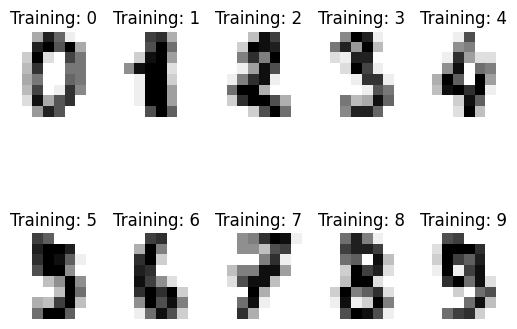

In [ ]:

# Load the dataset 

# View the data
print("Data shape:", digits.data.shape)
print("First sample data:")
print(digits.data[0])

# Visualize the first 10 samples
images_and_labels = list(zip(digits.images, digits.target))
for index, (image, label) in enumerate(images_and_labels[:10]):
    plt.subplot(2, 5, index + 1)
    plt.axis('off')
    plt.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title('Training: %i' % label)


### Exercise 1.3
Create and train (fit) a UMAP-reducer, then transform and visualise your data, e.g. doing something like:


/opt/anaconda3/envs/aml/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Text(0.5, 1.0, 'UMAP projection of the Digits dataset')

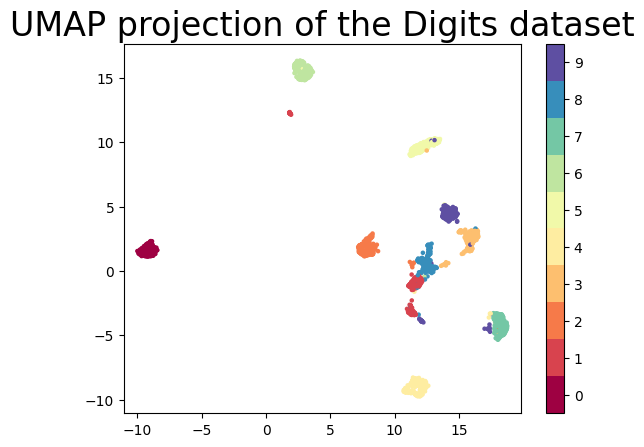

In [ ]:

# Reduce 64-dimensional data to 2D for visualization

# Create and train UMAP
reducer = umap.UMAP(random_state=42)
reducer.fit(digits.data)
embedding = reducer.transform(digits.data)

# Visualize the results
plt.scatter(embedding[:, 0], embedding[:, 1], c=digits.target, cmap='Spectral', s=5)
plt.gca().set_aspect('equal', 'datalim')
plt.colorbar(boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))
plt.title('UMAP projection of the Digits dataset', fontsize=24)


__Be prepared to explain, at least on a conceptual level, what it does__

# Exercise 2
Calculate the cosine-similarity (should be explained in lecture 2) of each sample against the means of the classes in the data set as following:

### Exercise 2.1
Calculate the "mean image" per class, ```mean_images``` 

In [ ]:


mean_images = []

# For each digit (0-9)
for digit in range(10):
    # Find all images of this digit
    mask = (digits.target == digit)
    digit_images = digits.data[mask]
    
    # Calculate mean
    mean_image = digit_images.mean(axis=0)
    mean_images.append(mean_image)

# Convert to numpy array
mean_images = np.array(mean_images)
print("Mean images shape:", mean_images.shape)  # Should be (10, 64)

Mean images shape: (10, 64)


### Exercise 2.2
Calculate the row-wise L2-norm for the raw data, i.e. the L2-norm over each image (check for example Numpy's linalg.norm for that) __and__ for the mean images you got from step the previous step.

In [ ]:

# Save original data
X = digits.data

# Calculate L2-norm (length) for each image
X_norms = np.linalg.norm(X, axis=1)

# Calculate L2-norm for mean images
mean_norms = np.linalg.norm(mean_images, axis=1)

print("Original image norms shape:", X_norms.shape)      # (1797,)
print("Mean image norms shape:", mean_norms.shape)       # (10,)


Original image norms shape: (1797,)
Mean image norms shape: (10,)


### Exercise 2.3
Calculate the cosine similarity matrix, ```similarities``` of the normalised raw data and mean image matrices. See https://en.wikipedia.org/wiki/Cosine_similarity. as a reminder. 

In [ ]:

# Normalize (divide by length to make each vector length 1)
X_normalized = X / X_norms[:, np.newaxis]
mean_normalized = mean_images / mean_norms[:, np.newaxis]

# Calculate similarity using matrix multiplication
similarities = X_normalized @ mean_normalized.T

print("Similarity matrix shape:", similarities.shape)  # (1797, 10)
print("Example - First image similarity with 10 digits:")
print(similarities[0])


Similarity matrix shape: (1797, 10)
Example - First image similarity with 10 digits:
[0.96953736 0.64057712 0.69033218 0.74642341 0.73680146 0.77826502
 0.73035169 0.69534056 0.78048386 0.82650128]


### Exercise 2.4
Plot the closest and "furthest" sample (images) for each class, i.e. where cosine similarity is highest / lowest together with the respective mean image. You can use the following plot routine as inspiration to get the images out with some meta data (```similarities``` is the matrix with all the cosine similarities):

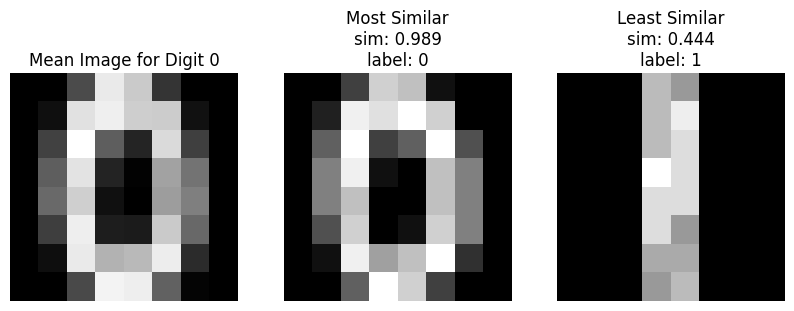

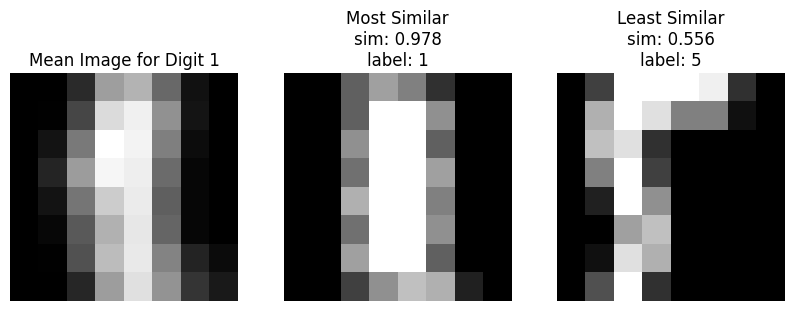

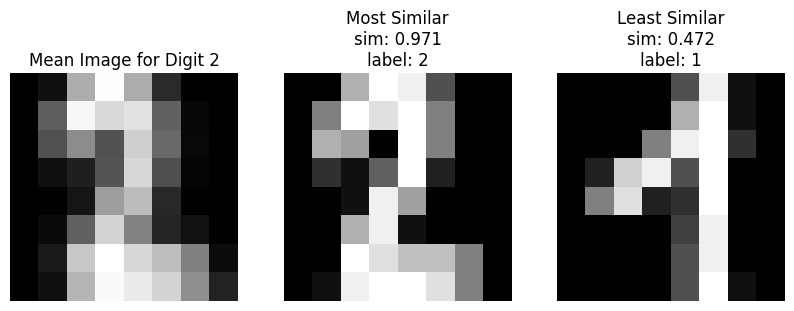

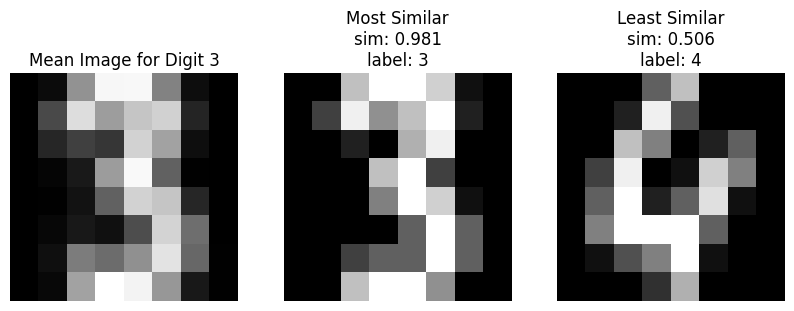

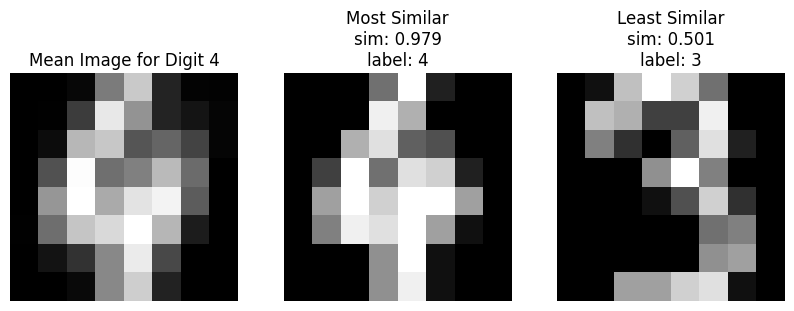

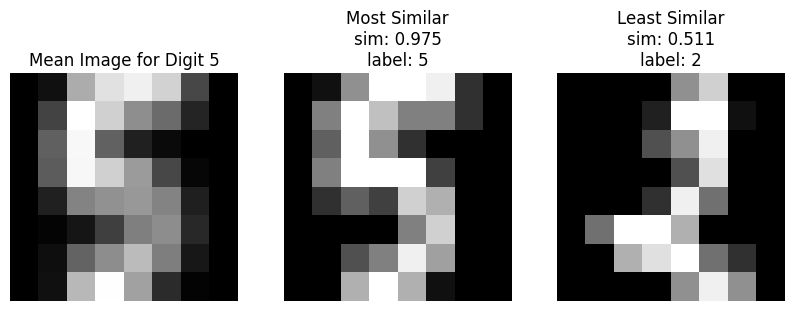

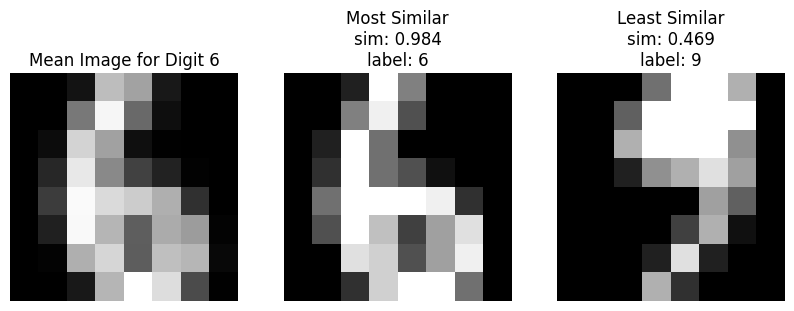

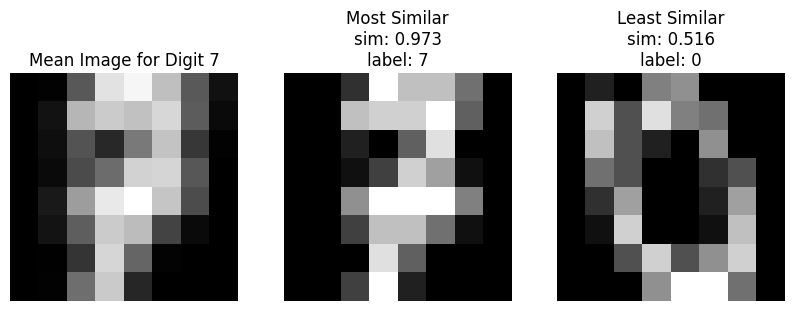

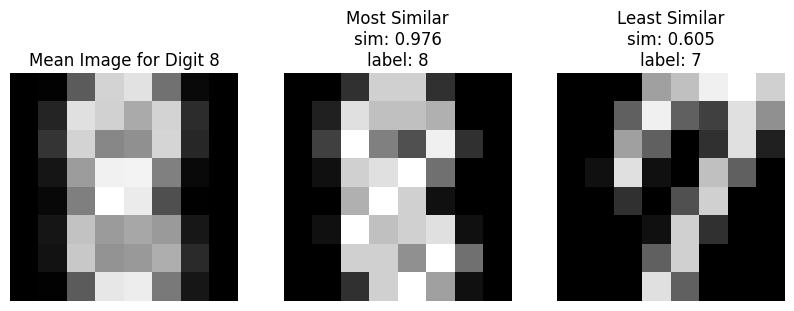

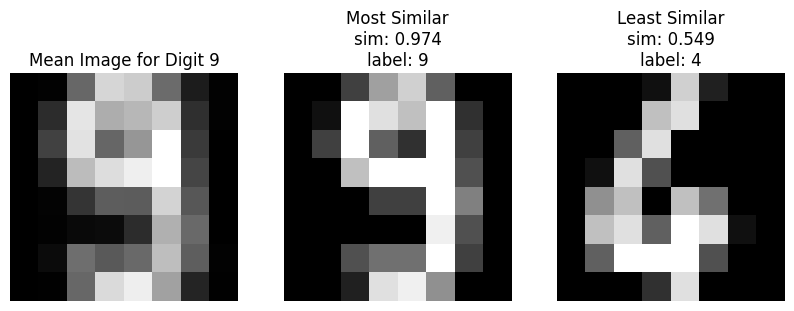

In [ ]:

for i in range(0, 10):
    # Find indices of minimum and maximum similarity
    min_idx = np.argmin(similarities[:, i])  # Least similar
    max_idx = np.argmax(similarities[:, i])  # Most similar
    
    # Create figure with 3 columns
    fig, axs = plt.subplots(1, 3, figsize=(10, 10))
    
    # Left: Mean image (reference)
    axs[0].set_title(f"Mean Image for Digit {i}")
    axs[0].imshow(mean_images[i].reshape(8, 8), cmap='gray')
    axs[0].axis('off')
    
    # Middle: Most similar sample
    axs[1].set_title(f"Most Similar\nsim: {similarities[max_idx, i]:.3f}\nlabel: {digits.target[max_idx]}")
    axs[1].imshow(X[max_idx].reshape(8, 8), cmap='gray')
    axs[1].axis('off')
    
    # Right: Least similar sample
    axs[2].set_title(f"Least Similar\nsim: {similarities[min_idx, i]:.3f}\nlabel: {digits.target[min_idx]}")
    axs[2].imshow(X[min_idx].reshape(8, 8), cmap='gray')
    axs[2].axis('off')
    
    plt.show()

__Be prepared to explain__ what you see and reflect upon it!

# Exercise 3
Split your data set into 70% training data (features and labels), and 30% test data (this will be used for the classifiers below). Use the method ```train_test_split``` from ```klearn.model_selection```. Set the ```random_state=13  ``` and ```stratify``` on the labels (so that the test set has the same number of each label).

In [ ]:

from sklearn.model_selection import train_test_split

# Prepare data
X = digits.data    # All image data (1797, 64)
y = digits.target  # All labels (1797,)

# Split data: 70% training, 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,                  # Features (images)
    y,                  # Labels (0-9)
    test_size=0.3,      # 30% for test set
    random_state=13,    # Fixed random seed 
    stratify=y          # Stratified sampling 
)

# View split results
print("="*50)
print("Data split completed!")
print("="*50)
print(f"Training features shape: {X_train.shape}")  # (1257, 64)
print(f"Test features shape: {X_test.shape}")       # (540, 64)
print(f"Training labels shape: {y_train.shape}")    # (1257,)
print(f"Test labels shape: {y_test.shape}")         # (540,)

print(f"\nData split ratio:")
total = len(X)
print(f"Total samples: {total}")
print(f"Training set: {len(X_train)} ({len(X_train)/total:.1%})")
print(f"Test set: {len(X_test)} ({len(X_test)/total:.1%})")


Data split completed!
Training features shape: (1257, 64)
Test features shape: (540, 64)
Training labels shape: (1257,)
Test labels shape: (540,)

Data split ratio:
Total samples: 1797
Training set: 1257 (69.9%)
Test set: 540 (30.1%)


# Exercise 4: k-NN
Process the data with a k-NN classifier as follows: 

### Exercise 4.1
Set up a ```sklearn.neighbors.KNeighborsClassifier``` as it comes in SciKitLearn with ```n_neighbors = 5, algorithm = 'brute'``` and otherwise default parameters

In [ ]:

# Create classifier 
classifier = KNeighborsClassifier(n_neighbors=5, algorithm='brute')

print("k-NN classifier created successfully!")
print("Parameters: k=5, algorithm=brute")

k-NN classifier created successfully!
Parameters: k=5, algorithm=brute


### Exercise 4.1
Prepare the classifier ("fit a model") with your training data

In [ ]:

# Train 
classifier.fit(X_train, y_train)

print("Training completed!")
print(f"Classifier memorized {len(X_train)} training samples")

Training completed!
Classifier memorized 1257 training samples


### Exercise 4.2
 Apply your classifier to the test data, i.e., get predictions for the test data
 

In [ ]:

# Predict on test set
predicted = classifier.predict(X_test)

print("Prediction completed!")
print(f"Predicted {len(X_test)} test samples")
print(f"\nFirst 10 predictions: {predicted[:10]}")
print(f"First 10 true labels: {y_test[:10]}")


Prediction completed!
Predicted 540 test samples

First 10 predictions: [3 6 8 0 3 2 5 8 0 5]
First 10 true labels: [8 6 8 0 3 2 5 8 0 5]


Get the nearest neighbors and the corresponding distances in the training set for each test sample  

In [ ]:
# Find 5 nearest neighbors for each test sample
distances, neighbors = classifier.kneighbors(X_test)

print("Found 5 nearest neighbors for each test sample")
print(f"Distance matrix shape: {distances.shape}")    # (540, 5)
print(f"Neighbor indices shape: {neighbors.shape}")   # (540, 5)

Found 5 nearest neighbors for each test sample
Distance matrix shape: (540, 5)
Neighbor indices shape: (540, 5)


Visualize the 5 nearest neighbors for a few test images (see tutorial)!

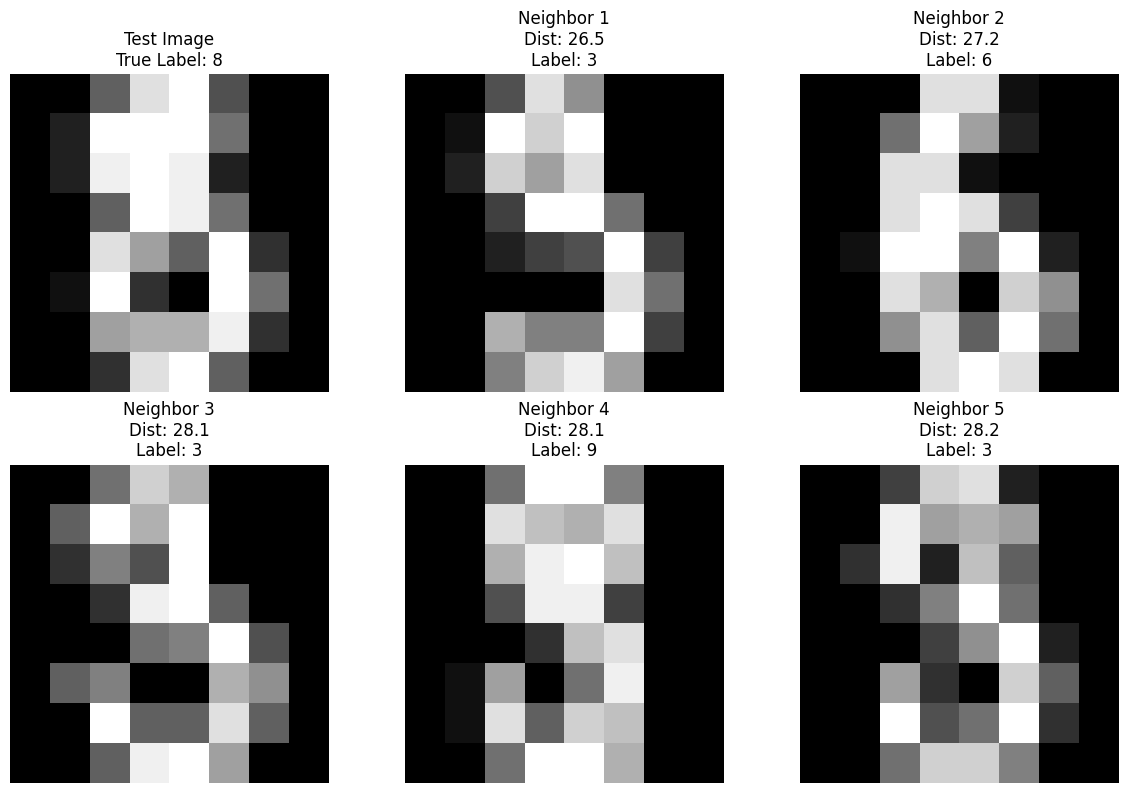

In [ ]:
# Visualize 5 nearest neighbors for the 1st test sample
test_idx = 0

# Create figure (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# First image: Test image
axes[0, 0].imshow(X_test[test_idx].reshape(8, 8), cmap='gray')
axes[0, 0].set_title(f'Test Image\nTrue Label: {y_test[test_idx]}')
axes[0, 0].axis('off')

# Next 5 images: Nearest neighbors
for i in range(5):
    row = (i + 1) // 3  # Which row
    col = (i + 1) % 3   # Which column
    
    # Get neighbor index and distance
    neighbor_idx = neighbors[test_idx][i]
    dist = distances[test_idx][i]
    
    # Display neighbor image
    neighbor_img = X_train[neighbor_idx].reshape(8, 8)
    axes[row, col].imshow(neighbor_img, cmap='gray')
    axes[row, col].set_title(
        f'Neighbor {i+1}\nDist: {dist:.1f}\nLabel: {y_train[neighbor_idx]}'
    )
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Exercise 4.3
Evaluate your classifier with the sklearn.metrics tools classification_report and confusion_matrix 

In [ ]:

# Classification report
print("Classification Report:")
print(metrics.classification_report(y_test, predicted))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.96      1.00      0.98        55
           2       0.98      0.98      0.98        53
           3       0.98      0.96      0.97        55
           4       1.00      0.98      0.99        54
           5       0.98      1.00      0.99        55
           6       1.00      1.00      1.00        54
           7       0.98      1.00      0.99        54
           8       0.96      0.94      0.95        52
           9       1.00      0.98      0.99        54

    accuracy                           0.99       540
   macro avg       0.99      0.99      0.99       540
weighted avg       0.99      0.99      0.99       540



and

In [ ]:
# Confusion matrix
print("\nConfusion Matrix:")
print(metrics.confusion_matrix(y_test, predicted))



混淆矩阵:
[[54  0  0  0  0  0  0  0  0  0]
 [ 0 55  0  0  0  0  0  0  0  0]
 [ 0  0 52  0  0  0  0  1  0  0]
 [ 0  0  1 53  0  1  0  0  0  0]
 [ 0  0  0  0 53  0  0  0  1  0]
 [ 0  0  0  0  0 55  0  0  0  0]
 [ 0  0  0  0  0  0 54  0  0  0]
 [ 0  0  0  0  0  0  0 54  0  0]
 [ 0  2  0  1  0  0  0  0 49  0]
 [ 0  0  0  0  0  0  0  0  1 53]]


# Exercise 5: k-Means
Cluster the data with k-Means as follows:

### Exercise 5.1
Set up a k-Means instance (```sklearn.cluster.KMeans```) with ```n_clusters=10```, ```n_init=100``` and ```random_state=42```.

In [ ]:

# Create clustering object
clustering = KMeans(
    n_clusters=10,      # 10 clusters (corresponding to 0-9)
    n_init=100,         # Initialize 100 times, select best
    random_state=42     # Fixed random seed
)

print("k-Means clustering created successfully!")


k-Means clustering created successfully!


### Exercise 5.2
Apply the clustering approach

In [ ]:

# Perform clustering on training set
clustering.fit(X_train)

# Get cluster labels
cluster_labels = clustering.labels_

print("Clustering completed!")
print(f"Each training sample assigned to a cluster (0-9)")


Clustering completed!
Each training sample assigned to a cluster (0-9)


### Exercise 5.3
Visualise the found cluster centers (you can get them using <clustering>.cluster_centers_); those are in principle also images, but maybe not as clearly interpretable as you would have hoped for. Compare what you see with the scatter plot you got from UMAP, i.e. find k-Means-clusters (visualised as cluster center images) and corresponding UMAP-plot-clusters (visualised as blobs or scattered dots in the plot) that are clearly distinct from everything else or others that seem to be "all the same" or at least very close.

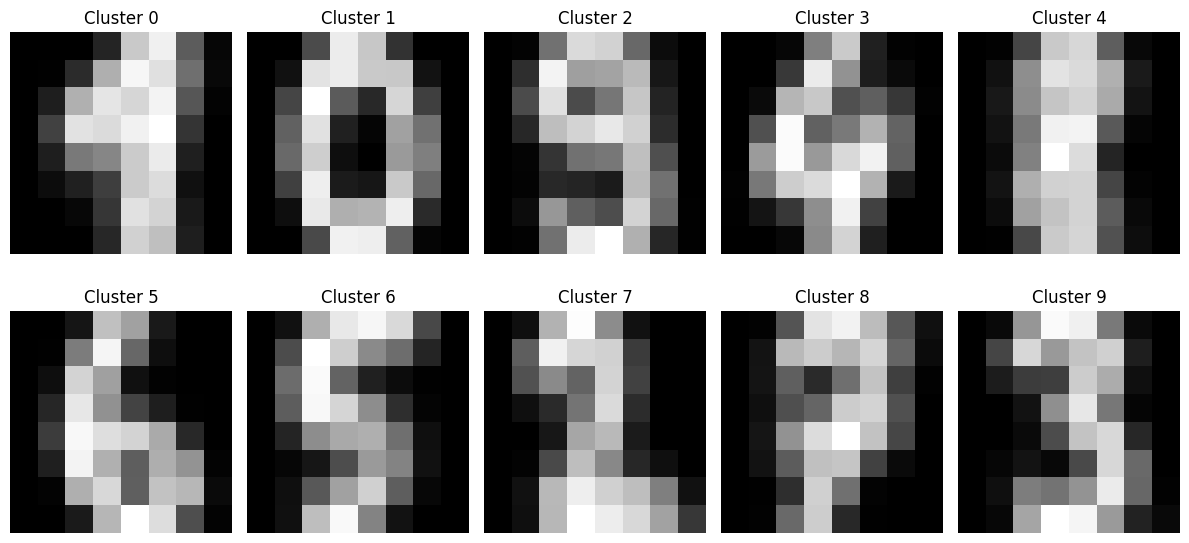

These images may be blurry because they are average values


In [ ]:

# Display 10 cluster centers (as images)
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i in range(10):
    row = i // 5
    col = i % 5
    
    # Reshape cluster center to 8×8 image
    center_img = clustering.cluster_centers_[i].reshape(8, 8)
    
    axes[row, col].imshow(center_img, cmap='gray')
    axes[row, col].set_title(f'Cluster {i}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print("These images may be blurry because they are average values")


### Exercise 5.4
Investigate at least the following evaluation tools in the SciKitLearn documentation: ```metrics.completeness_score( <labels>, <cluster-labels>)``` and 
```metrics.homogeneity_score( <labels>, <cluster-labels>)```

For those to work you should run a prediction step over the training data (into cluster-labels). Rough numbers for what those measures should be can be found in the check list.

In [ ]:

# Predict on training set (for evaluation)
train_cluster_labels = clustering.predict(X_train)

# Homogeneity score
homogeneity = metrics.homogeneity_score(y_train, train_cluster_labels)

# Completeness score
completeness = metrics.completeness_score(y_train, train_cluster_labels)

print("Clustering Evaluation:")
print(f"Homogeneity: {homogeneity:.3f}")
print(f"Completeness: {completeness:.3f}")

Clustering Evaluation:
Homogeneity: 0.749
Completeness: 0.758


For the interested: Try also the following score (the main concept is the mutual information score, the adjusted mutual information score is an improved variant) and give its documentation some thoughts, discuss it with your partner and in the peer review (it should make more sense after the information theory lecture, but there is also some intuition in it, that you can reflect upon)

In [ ]:

ami_score = metrics.adjusted_mutual_info_score(y_train, train_cluster_labels)
print(f"\nAdjusted Mutual Information: {ami_score:.3f}")



Adjusted Mutual Information: 0.750


### Exercise 5.5
For each cluster, assign a label by taking the most common label of the training data assigned to the cluster. 


In [ ]:

# Create cluster-to-label mapping dictionary
cluster_to_label = {}

# For each cluster
for i in range(10):
    # Find all samples in this cluster
    mask = (train_cluster_labels == i)
    labels = y_train[mask]
    
    # Find most common label (voting)
    most_common_label = Counter(labels).most_common(1)[0][0]
    
    # Assign label
    cluster_to_label[i] = most_common_label

print("Cluster-to-label mapping:")
for c, l in cluster_to_label.items():
    print(f"Cluster {c} → Digit {l}")

Cluster-to-label mapping:
Cluster 0 → Digit 1
Cluster 1 → Digit 0
Cluster 2 → Digit 9
Cluster 3 → Digit 4
Cluster 4 → Digit 8
Cluster 5 → Digit 6
Cluster 6 → Digit 5
Cluster 7 → Digit 2
Cluster 8 → Digit 7
Cluster 9 → Digit 3


### Exercise 5.6
Use the clustering result from the previous exercise to do a prediction for the test data and evaluate the result. It should be quite bad. 

In [ ]:

# Predict cluster assignments for test set
test_clusters = clustering.predict(X_test)

# Convert cluster labels to digit labels
predicted_labels = np.array([cluster_to_label[c] for c in test_clusters])

# Evaluate performance
accuracy = (predicted_labels == y_test).sum() / len(y_test)
print(f"\nClustering prediction accuracy: {accuracy:.2%}")
print("(Much worse than k-NN, which is normal!)")

# Confusion matrix
print("\nConfusion Matrix:")
print(metrics.confusion_matrix(y_test, predicted_labels))



Clustering prediction accuracy: 79.07%
(Much worse than k-NN, which is normal!)

Confusion Matrix:
[[53  0  0  0  1  0  0  0  0  0]
 [ 0 19  7  0  0  1  0  0 28  0]
 [ 1  0 43  3  0  0  0  3  3  0]
 [ 0  0  1 45  0  2  0  2  0  5]
 [ 0  4  0  0 47  0  0  1  2  0]
 [ 0  0  0  1  0 42  0  0  0 12]
 [ 0  0  0  0  0  0 53  0  1  0]
 [ 0  2  0  0  0  0  0 52  0  0]
 [ 0  1  1  2  0  1  0  3 26 18]
 [ 0  0  0  1  0  3  0  2  1 47]]

聚类预测准确率: 79.07%
（比k-NN差很多，这是正常的！）

混淆矩阵:
[[53  0  0  0  1  0  0  0  0  0]
 [ 0 19  7  0  0  1  0  0 28  0]
 [ 1  0 43  3  0  0  0  3  3  0]
 [ 0  0  1 45  0  2  0  2  0  5]
 [ 0  4  0  0 47  0  0  1  2  0]
 [ 0  0  0  1  0 42  0  0  0 12]
 [ 0  0  0  0  0  0 53  0  1  0]
 [ 0  2  0  0  0  0  0 52  0  0]
 [ 0  1  1  2  0  1  0  3 26 18]
 [ 0  0  0  1  0  3  0  2  1 47]]
